### Gizli katmanı ve embedding boyutunu büyütüp dev loss'un nasıl değiştiğini göster. Embedding'leri 2 boyutta çizdir: hangi harfler birbirine yakın düşüyor? Modelden isimler örnekle, bigram'ınkilerle karşılaştır.

In [8]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline


In [9]:
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [10]:


block_size = 3
def build_dataset(words):  
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


### Vektör boyutu: 10 hidden layer nöron sayısı: 200

In [11]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

print("Toplam parametre sayısı:", sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

Toplam parametre sayısı: 11897


In [12]:

for i in range(30000):
  # minibatch 
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 20000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

# Dev loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss_dev = F.cross_entropy(logits, Ydev)
print("Büyük Model Dev Loss: %.4f" % loss_dev.item())
print("Küçük model dev loss 2.35 ")

Büyük Model Dev Loss: 2.2851
Küçük model dev loss 2.35 


### 2 Boyutlu Embedding Görselleştirme

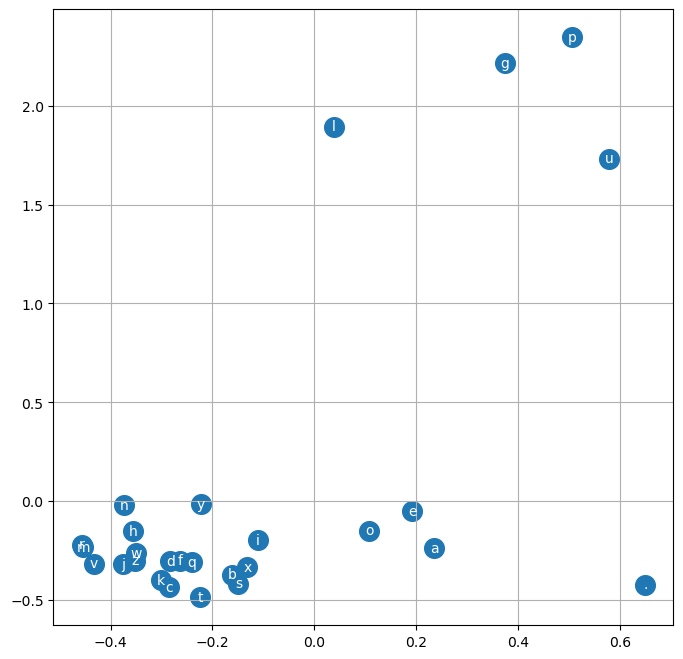

In [13]:

g2 = torch.Generator().manual_seed(2147483647)
C_2d = torch.randn((27, 2), generator=g2)
W1_2d = torch.randn((6, 100), generator=g2)
b1_2d = torch.randn(100, generator=g2)
W2_2d = torch.randn((100, 27), generator=g2)
b2_2d = torch.randn(27, generator=g2)
params_2d = [C_2d, W1_2d, b1_2d, W2_2d, b2_2d]
for p in params_2d: p.requires_grad = True

for i in range(10000):
  ix = torch.randint(0, Xtr.shape[0], (32,))
  emb = C_2d[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 6) @ W1_2d + b1_2d)
  logits = h @ W2_2d + b2_2d
  loss = F.cross_entropy(logits, Ytr[ix])
  for p in params_2d: p.grad = None
  loss.backward()
  for p in params_2d: p.data += -0.1 * p.grad

plt.figure(figsize=(8,8))
plt.scatter(C_2d[:,0].data, C_2d[:,1].data, s=200)
for i in range(C_2d.shape[0]):
    plt.text(C_2d[i,0].item(), C_2d[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')
plt.show()

In [14]:

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

mona.
kayah.
seel.
nihah.
larethan.
eng.
len.
adered.
eliighmi.
jenleigh.
esnanar.
katelvintelin.
sheber.
shiriel.
kinde.
jelipanteron.
ubu.
ged.
riyah.
fiel.
